## STEP 0: Import Data

In [40]:
import pandas as pd
import numpy as np
import pickle

# Load the pre-calculated features
with open('artist_features_fortest.pkl', 'rb') as f:
    features = pickle.load(f)

print(features.keys())


dict_keys(['artist_stats_lookup_T', 'top_15_collabs_list_T', 'artist_popularity_lookup_T', 'global_mean_popularity_T'])


In [41]:
artist_stats_lookup = features['artist_stats_lookup_T']
top_15_collabs_list = features['top_15_collabs_list_T']
artist_popularity_lookup = features['artist_popularity_lookup_T']
global_mean_popularity = features['global_mean_popularity_T']


print(f" artist_stats_lookup: {len(artist_stats_lookup):,} artists")
print(f" top_15_collabs_list: {len(top_15_collabs_list)} collaborators")
print(f" artist_popularity_lookup: {len(artist_popularity_lookup):,} artists")
print(f" global_mean_popularity: {global_mean_popularity:.2f}")

 artist_stats_lookup: 1,258 artists
 top_15_collabs_list: 15 collaborators
 artist_popularity_lookup: 1,803 artists
 global_mean_popularity: 69.23


## STEP 1: Temporal Features (Simple)
Extract from release_date column
Temperoal features compute for all train/val/test sets

In [43]:
# Load the aggregated dataset
agg_df = pd.read_csv('aggregated_dataset.csv', sep=';')
print(f"Loaded aggregated dataset: {len(agg_df):,} rows")
print(f"  - Train: {(agg_df['split'] == 'train').sum():,} rows")
print(f"  - Validate: {(agg_df['split'] == 'val').sum():,} rows")
print(f"  - Test: {(agg_df['split'] == 'test').sum():,} rows")
print(agg_df.head())


agg_df['first_appearance'] = pd.to_datetime(agg_df['first_appearance'])


agg_df['release_year'] = agg_df['first_appearance'].dt.year
agg_df['release_quarter'] = agg_df['first_appearance'].dt.quarter
agg_df['release_month'] = agg_df['first_appearance'].dt.month
agg_df['release_day_of_week'] = agg_df['first_appearance'].dt.dayofweek
agg_df['is_friday_release'] = (agg_df['release_day_of_week'] == 4).astype(int)
agg_df['is_holiday_season'] = agg_df['release_month'].isin([11, 12]).astype(int)



# Split into train, validate, and test
train_df = agg_df[agg_df['split'] == 'train'].copy()
val_df = agg_df[agg_df['split'] == 'val'].copy()
test_df = agg_df[agg_df['split'] == 'test'].copy()

print(f"\nTemporal Features Summary (Train Set):")
print(f"  - release_year: {train_df['release_year'].min()} to {train_df['release_year'].max()}")
print(f"  - release_quarter: {train_df['release_quarter'].value_counts().sort_index().to_dict()}")
print(f"  - is_friday_release: {train_df['is_friday_release'].sum():,} Friday releases ({train_df['is_friday_release'].mean()*100:.1f}%)")
print(f"  - is_holiday_season: {train_df['is_holiday_season'].sum():,} holiday releases ({train_df['is_holiday_season'].mean()*100:.1f}%)")


Loaded aggregated dataset: 9,161 rows
  - Train: 6,158 rows
  - Validate: 1,414 rows
  - Test: 1,589 rows
                       id  best_rank    avg_rank  total_weeks_charted  \
0  000xQL6tZNLJzIrtIgxqSl         40  101.500000                  118   
1  003VDDA7J3Xb2ZFlNx7nIZ        108  138.000000                    2   
2  003eoIwxETJujVWmNFMoZy         91  136.500000                   14   
3  003vvx7Niy0yvhvHt4a68B         73  168.069643                  560   
4  00B7TZ0Xawar6NZ00JFomN         61  109.285714                   14   

  first_appearance last_appearance                                 Title  \
0       2017-03-24      2017-09-12  Still Got Time (feat. PARTYNEXTDOOR)   
1       2020-02-07      2020-02-08                               YELL OH   
2       2018-06-15      2018-06-28                         Growing Pains   
3       2020-08-15      2023-01-01                        Mr. Brightside   
4       2018-04-06      2018-04-19   Best Life (feat. Chance The Rapper)   

In [44]:
print(f"Train set songs: {train_df['id'].nunique():,}")
print(f"Validation set songs: {val_df['id'].nunique():,}")
print(f"Test set songs: {test_df['id'].nunique():,}")


Train set songs: 6,158
Validation set songs: 1,414
Test set songs: 1,589


### Combine Train and Validation

In [45]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_df.shape

(7572, 26)

In [46]:
train_val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7572 entries, 0 to 7571
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   7572 non-null   object        
 1   best_rank            7572 non-null   int64         
 2   avg_rank             7572 non-null   float64       
 3   total_weeks_charted  7572 non-null   int64         
 4   first_appearance     7572 non-null   datetime64[ns]
 5   last_appearance      7572 non-null   object        
 6   Title                7572 non-null   object        
 7   Artist               7572 non-null   object        
 8   peak_score           7572 non-null   float64       
 9   longevity_score      7572 non-null   float64       
 10  popularity_score     7572 non-null   float64       
 11  popularity_label     7572 non-null   object        
 12  split                7572 non-null   object        
 13  Danceability         7572 non-nul

## STEP 2: Artist Features
Use artist_stats_lookup to create 3 features
Extract primary artist for TRAIN+Val and Test


2A: Extract Primary Artist from 'Artists' Column

In [47]:
def extract_primary_artist(artists_string):

    artists = [a.strip() for a in str(artists_string).split(',')]
    return artists[0]  # First artist is primary


train_val_df['primary_artist'] = train_val_df['Artist'].apply(extract_primary_artist)
test_df['primary_artist'] = test_df['Artist'].apply(extract_primary_artist)

print("Primary artist extracted for train+val and Test")
print(f"\nTrain set unique artists: {train_val_df['primary_artist'].nunique():,}")
print(f"Val set unique artists: {test_df['primary_artist'].nunique():,}")

# Sample
print("\nSample (Train):")
print(train_val_df[['Artist', 'primary_artist']].head(10))



Primary artist extracted for train+val and Test

Train set unique artists: 1,245
Val set unique artists: 533

Sample (Train):
         Artist primary_artist
0          ZAYN           ZAYN
1  Trippie Redd   Trippie Redd
2  Alessia Cara   Alessia Cara
3   The Killers    The Killers
4       Cardi B        Cardi B
5        Thalia         Thalia
6          Kygo           Kygo
7  Busta Rhymes   Busta Rhymes
8  Fall Out Boy   Fall Out Boy
9         DJ A1          DJ A1


In [48]:
train_val_df.head()

,id,best_rank,avg_rank,total_weeks_charted,first_appearance,last_appearance,Title,Artist,peak_score,longevity_score,...,Acousticness,Instrumentalness,Valence,release_year,release_quarter,release_month,release_day_of_week,is_friday_release,is_holiday_season,primary_artist
0,000xQL6tZNLJzIrtIgxqSl,40,101.500000,118,2017-03-24,2017-09-12,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,80.5,100.0,...,0.131,0.0,0.524,2017,1,3,4,1,0,ZAYN
1,003VDDA7J3Xb2ZFlNx7nIZ,108,138.000000,2,2020-02-07,2020-02-08,YELL OH,Trippie Redd,46.5,10.0,...,0.004,0.0,0.190,2020,1,2,4,1,0,Trippie Redd
2,003eoIwxETJujVWmNFMoZy,91,136.500000,14,2018-06-15,2018-06-28,Growing Pains,Alessia Cara,55.0,70.0,...,0.082,0.0,0.437,2018,2,6,4,1,0,Alessia Cara
3,003vvx7Niy0yvhvHt4a68B,73,168.069643,560,2020-08-15,2023-01-01,Mr. Brightside,The Killers,64.0,100.0,...,0.001,0.0,0.236,2020,3,8,5,0,0,The Killers
4,00B7TZ0Xawar6NZ00JFomN,61,109.285714,14,2018-04-06,2018-04-19,Best Life (feat. Chance The Rapper),Cardi B,70.0,70.0,...,0.287,0.0,0.665,2018,2,4,4,1,0,Cardi B


In [49]:
test_df.head()

,id,best_rank,avg_rank,total_weeks_charted,first_appearance,last_appearance,Title,Artist,peak_score,longevity_score,...,Acousticness,Instrumentalness,Valence,release_year,release_quarter,release_month,release_day_of_week,is_friday_release,is_holiday_season,primary_artist
7572,00Ga884hbpVvCNyeQdle1U,99,149.000000,2,2023-03-10,2023-03-11,Violet Chemistry,Miley Cyrus,51.0,10.0,...,0.003,0.000,0.588,2023,1,3,4,1,0,Miley Cyrus
7573,00I41xsW6SunZDJ5fB8KAd,65,65.000000,1,2022-07-15,2022-07-15,Safety Zone,j-hope,68.0,5.0,...,0.561,0.000,0.694,2022,3,7,4,1,0,j-hope
7574,00imgaPlYRrMGn9o83hfmk,44,111.666667,3,2022-07-08,2022-07-10,LOOSE CHANGE,Brent Faiyaz,78.5,15.0,...,0.753,0.000,0.440,2022,3,7,4,1,0,Brent Faiyaz
7575,01VzuxoBYMAJLObfU0w6dI,195,195.000000,1,2022-07-08,2022-07-08,ADDICTIONS (FEAT. Tre' Amani),Brent Faiyaz,3.0,5.0,...,0.021,0.000,0.843,2022,3,7,4,1,0,Brent Faiyaz
7576,01kfSdF9zfcDLri5sSWEoL,173,183.500000,4,2022-09-10,2022-09-18,RAVE,Dxrk ãƒ€ãƒ¼ã‚¯,14.0,20.0,...,0.235,0.849,0.338,2022,3,9,5,0,0,Dxrk ãƒ€ãƒ¼ã‚¯


2B: Look Up Artist Statistics

In [10]:
print(artist_stats_lookup)

{'Taylor Swift': {'song_count': 174, 'avg_rank': 102.52, 'best_rank': 1}, 'Drake': {'song_count': 138, 'avg_rank': 96.15, 'best_rank': 1}, 'BTS': {'song_count': 100, 'avg_rank': 89.91, 'best_rank': 1}, 'Future': {'song_count': 99, 'avg_rank': 103.37, 'best_rank': 3}, 'Juice WRLD': {'song_count': 98, 'avg_rank': 100.35, 'best_rank': 2}, 'Eminem': {'song_count': 79, 'avg_rank': 127.91, 'best_rank': 1}, 'Ariana Grande': {'song_count': 78, 'avg_rank': 87.39, 'best_rank': 1}, 'Post Malone': {'song_count': 77, 'avg_rank': 88.54, 'best_rank': 1}, 'Logic': {'song_count': 76, 'avg_rank': 95.71, 'best_rank': 2}, 'Ed Sheeran': {'song_count': 72, 'avg_rank': 104.27, 'best_rank': 1}, 'Trippie Redd': {'song_count': 67, 'avg_rank': 128.93, 'best_rank': 14}, 'Bad Bunny': {'song_count': 66, 'avg_rank': 82.46, 'best_rank': 1}, 'Migos': {'song_count': 64, 'avg_rank': 106.14, 'best_rank': 8}, 'XXXTENTACION': {'song_count': 63, 'avg_rank': 117.03, 'best_rank': 1}, 'Lil Uzi Vert': {'song_count': 58, 'avg_ra

In [50]:
all_avg_ranks = [stats['avg_rank'] for stats in artist_stats_lookup.values()]
all_best_ranks = [stats['best_rank'] for stats in artist_stats_lookup.values()]

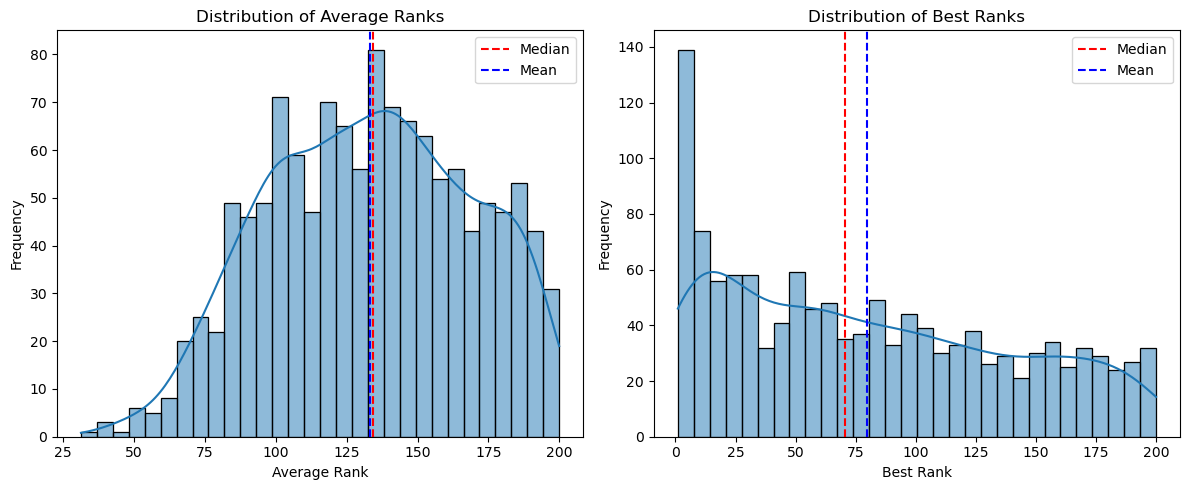

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.figure(figsize=(12,5))

# --- Average Rank ---
plt.subplot(1, 2, 1)
sns.histplot(all_avg_ranks, bins=30, kde=True)
plt.axvline(np.median(all_avg_ranks), color='red', linestyle='--', label='Median')
plt.axvline(np.mean(all_avg_ranks), color='blue', linestyle='--', label='Mean')
plt.title('Distribution of Average Ranks')
plt.xlabel('Average Rank')
plt.ylabel('Frequency')
plt.legend()

# --- Best Rank ---
plt.subplot(1, 2, 2)
sns.histplot(all_best_ranks, bins=30, kde=True)
plt.axvline(np.median(all_best_ranks), color='red', linestyle='--', label='Median')
plt.axvline(np.mean(all_best_ranks), color='blue', linestyle='--', label='Mean')
plt.title('Distribution of Best Ranks')
plt.xlabel('Best Rank')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

In [52]:

all_song_counts = [stats['song_count'] for stats in artist_stats_lookup.values()]
all_avg_ranks = [stats['avg_rank'] for stats in artist_stats_lookup.values()]
all_best_ranks = [stats['best_rank'] for stats in artist_stats_lookup.values()]

artist_fallback = {
    'song_count': 1,                              
    'avg_rank': np.median(all_avg_ranks),      
    'best_rank': np.median(all_best_ranks)       
}

print(f"Fallback values calculated from {len(artist_stats_lookup):,} artists:")
print(f"  - song_count: {artist_fallback['song_count']}")
print(f"  - avg_rank: {artist_fallback['avg_rank']:.2f}")
print(f"  - best_rank: {artist_fallback['best_rank']:.2f}")

Fallback values calculated from 1,258 artists:
  - song_count: 1
  - avg_rank: 134.26
  - best_rank: 70.50


In [54]:
def get_artist_features(primary_artist, artist_stats_lookup):
    """
    Look up artist statistics from pre-calculated lookup
    Returns: (song_count, avg_rank, best_rank)
    """
    if primary_artist in artist_stats_lookup:
        stats = artist_stats_lookup[primary_artist]
        return (
            stats['song_count'],
            stats['avg_rank'],
            stats['best_rank']
        )
    else:
      
        return (
            artist_fallback['song_count'],
            artist_fallback['avg_rank'],
            artist_fallback['best_rank']
        )
# Apply to train set

artist_features_train = train_val_df['primary_artist'].apply(
    lambda x: get_artist_features(x, artist_stats_lookup)
)

# Split into separate columns for train
train_val_df['artist_song_count'] = artist_features_train.apply(lambda x: x[0])
train_val_df['artist_avg_rank'] = artist_features_train.apply(lambda x: x[1])
train_val_df['artist_best_rank'] = artist_features_train.apply(lambda x: x[2])

# Apply to test set

artist_features_val = test_df['primary_artist'].apply(
    lambda x: get_artist_features(x, artist_stats_lookup)
)

# Split into separate columns for val
test_df['artist_song_count'] = artist_features_val.apply(lambda x: x[0])
test_df['artist_avg_rank'] = artist_features_val.apply(lambda x: x[1])
test_df['artist_best_rank'] = artist_features_val.apply(lambda x: x[2])

print("\n Artist features created for train and val with data-driven fallback!")

# Summary statistics
print("\nArtist Features Summary (Train+Val Set):")
print(train_val_df[['artist_song_count', 'artist_avg_rank', 'artist_best_rank']].describe())

print("\n Artist Features Summary (test Set):")
print(test_df[['artist_song_count', 'artist_avg_rank', 'artist_best_rank']].describe())

# Check for fallback usage (updated condition)
train_val_fallback = (train_val_df['artist_song_count'] == artist_fallback['song_count']) & \
                 (train_val_df['artist_avg_rank'] == artist_fallback['avg_rank'])
test_fallback = (test_df['artist_song_count'] == artist_fallback['song_count']) & \
               (test_df['artist_avg_rank'] == artist_fallback['avg_rank'])

print(f"\n Fallback Usage:")
print(f"  - Train+Val: {train_val_fallback.sum():,} artists not found ({train_val_fallback.mean()*100:.1f}%)")
print(f"  - Test: {test_fallback.sum():,} artists not found ({test_fallback.mean()*100:.1f}%)")

# Sample results
print("\n Sample Results (Train):")
print(train_val_df[['primary_artist', 'artist_song_count', 'artist_avg_rank', 'artist_best_rank']].head(10))


 Artist features created for train and val with data-driven fallback!

Artist Features Summary (Train+Val Set):
       artist_song_count  artist_avg_rank  artist_best_rank
count        7572.000000      7572.000000       7572.000000
mean           32.214078       114.147321         30.098587
std            36.592232        27.333741         42.403618
min             1.000000        31.200000          1.000000
25%             7.000000        95.710000          2.000000
50%            20.000000       105.670000          9.000000
75%            43.000000       131.710000         44.000000
max           174.000000       200.000000        200.000000

 Artist Features Summary (test Set):
       artist_song_count  artist_avg_rank  artist_best_rank
count        1589.000000      1589.000000        1589.00000
mean           22.925739       119.040463          41.18219
std            36.893895        25.267695          40.46281
min             1.000000        31.200000           1.00000
25%      

In [55]:
train_val_fallback.describe()

count      7572
unique        2
top       False
freq       7567
dtype: object

In [56]:
train_val_df.head()

,id,best_rank,avg_rank,total_weeks_charted,first_appearance,last_appearance,Title,Artist,peak_score,longevity_score,...,release_year,release_quarter,release_month,release_day_of_week,is_friday_release,is_holiday_season,primary_artist,artist_song_count,artist_avg_rank,artist_best_rank
0,000xQL6tZNLJzIrtIgxqSl,40,101.500000,118,2017-03-24,2017-09-12,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,80.5,100.0,...,2017,1,3,4,1,0,ZAYN,22,92.16,2.0
1,003VDDA7J3Xb2ZFlNx7nIZ,108,138.000000,2,2020-02-07,2020-02-08,YELL OH,Trippie Redd,46.5,10.0,...,2020,1,2,4,1,0,Trippie Redd,67,128.93,14.0
2,003eoIwxETJujVWmNFMoZy,91,136.500000,14,2018-06-15,2018-06-28,Growing Pains,Alessia Cara,55.0,70.0,...,2018,2,6,4,1,0,Alessia Cara,8,105.03,18.0
3,003vvx7Niy0yvhvHt4a68B,73,168.069643,560,2020-08-15,2023-01-01,Mr. Brightside,The Killers,64.0,100.0,...,2020,3,8,5,0,0,The Killers,6,173.24,73.0
4,00B7TZ0Xawar6NZ00JFomN,61,109.285714,14,2018-04-06,2018-04-19,Best Life (feat. Chance The Rapper),Cardi B,70.0,70.0,...,2018,2,4,4,1,0,Cardi B,24,78.15,1.0


In [17]:
test_df.head()

,id,best_rank,avg_rank,total_weeks_charted,first_appearance,last_appearance,Title,Artist,peak_score,longevity_score,...,release_year,release_quarter,release_month,release_day_of_week,is_friday_release,is_holiday_season,primary_artist,artist_song_count,artist_avg_rank,artist_best_rank
7572,00Ga884hbpVvCNyeQdle1U,99,149.000000,2,2023-03-10,2023-03-11,Violet Chemistry,Miley Cyrus,51.0,10.0,...,2023,1,3,4,1,0,Miley Cyrus,32,92.800,5.0
7573,00I41xsW6SunZDJ5fB8KAd,65,65.000000,1,2022-07-15,2022-07-15,Safety Zone,j-hope,68.0,5.0,...,2022,3,7,4,1,0,j-hope,2,134.000,92.0
7574,00imgaPlYRrMGn9o83hfmk,44,111.666667,3,2022-07-08,2022-07-10,LOOSE CHANGE,Brent Faiyaz,78.5,15.0,...,2022,3,7,4,1,0,Brent Faiyaz,4,137.540,39.0
7575,01VzuxoBYMAJLObfU0w6dI,195,195.000000,1,2022-07-08,2022-07-08,ADDICTIONS (FEAT. Tre' Amani),Brent Faiyaz,3.0,5.0,...,2022,3,7,4,1,0,Brent Faiyaz,4,137.540,39.0
7576,01kfSdF9zfcDLri5sSWEoL,173,183.500000,4,2022-09-10,2022-09-18,RAVE,Dxrk ãƒ€ãƒ¼ã‚¯,14.0,20.0,...,2022,3,9,5,0,0,Dxrk ãƒ€ãƒ¼ã‚¯,1,134.265,70.5


In [57]:
# Verify fallback values are correctly applied
print("\n" + "=" * 100)
print("VERIFICATION: Confirming Fallback Values Applied to Unknown Artists")
print("=" * 100)

# Identify unknown artists in train+val set
train_val_unknown = train_val_df[train_val_fallback].copy()
print(f"\n TRAIN+Val SET - Unknown Artists:")
print(f"Total songs with unknown artists: {len(train_val_unknown)}")

if len(train_val_unknown) > 0:
    # Check if all have exact fallback values
    all_correct_train = (
        (train_val_unknown['artist_song_count'] == artist_fallback['song_count']).all() and
        (train_val_unknown['artist_avg_rank'] == artist_fallback['avg_rank']).all() and
        (train_val_unknown['artist_best_rank'] == artist_fallback['best_rank']).all()
    )
    print(f" All using fallback ({artist_fallback['song_count']}, {artist_fallback['avg_rank']:.2f}, {artist_fallback['best_rank']:.2f}): {all_correct_train}")
    
    if all_correct_train:
        print("\n VERIFIED: All unknown artists in train set have correct fallback values")
    else:
        print("\n WARNING: Some unknown artists don't have correct fallback values!")
    
    print("\nUnknown artists in train:")
    print(train_val_unknown[['primary_artist', 'artist_song_count', 'artist_avg_rank', 'artist_best_rank']])
else:
    print(" No unknown artists in train set (expected - all should be in lookup)")

# Identify unknown artists in validation set
test_unknown = test_df[test_fallback].copy()
print(f"\nVALIDATION SET - Unknown Artists:")
print(f"Total songs with unknown artists: {len(test_unknown)} ({len(test_unknown)/len(test_df)*100:.1f}% of val set)")

if len(test_unknown) > 0:
    # Check if all have exact fallback values
    all_correct_test = (
        (test_unknown['artist_song_count'] == artist_fallback['song_count']).all() and
        (test_unknown['artist_avg_rank'] == artist_fallback['avg_rank']).all() and
        (test_unknown['artist_best_rank'] == artist_fallback['best_rank']).all()
    )
    print(f"All using fallback ({artist_fallback['song_count']}, {artist_fallback['avg_rank']:.2f}, {artist_fallback['best_rank']:.2f}): {all_correct_test}")
    
    if all_correct_test:
        print("\n VERIFIED: All unknown artists in Test set have correct fallback values")
    else:
        print("\n WARNING: Some unknown artists don't have correct fallback values!")
    
    print(f"\nFirst 10 unknown artists in Test:")
    print(test_unknown[['primary_artist', 'artist_song_count', 'artist_avg_rank', 'artist_best_rank']].head(10))
    
    # Show unique unknown artists
    unique_unknown = test_unknown['primary_artist'].nunique()
    print(f"\nUnique unknown artists in Test: {unique_unknown}")

print("\n" + "=" * 100)
print("FINAL VERIFICATION SUMMARY:")
print("=" * 100)
print(f"Fallback values: song_count={artist_fallback['song_count']}, avg_rank={artist_fallback['avg_rank']:.2f}, best_rank={artist_fallback['best_rank']:.2f}")
print(f"Train+Val: {len(train_val_unknown)} songs using fallback")
print(f"Test: {len(test_unknown)} songs using fallback")
print(f" All fallback values correctly applied: {all_correct_train if len(train_val_unknown) > 0 else True} (train+Val), {all_correct_test} (test)")


VERIFICATION: Confirming Fallback Values Applied to Unknown Artists

 TRAIN+Val SET - Unknown Artists:
Total songs with unknown artists: 5
 All using fallback (1, 134.26, 70.50): True

 VERIFIED: All unknown artists in train set have correct fallback values

Unknown artists in train:
           primary_artist  artist_song_count  artist_avg_rank  \
325    Humberto & Ronaldo                  1          134.265   
3498            Burna Boy                  1          134.265   
6448    Matheus Fernandes                  1          134.265   
6805  Fernando & Sorocaba                  1          134.265   
7181    Matheus Fernandes                  1          134.265   

      artist_best_rank  
325               70.5  
3498              70.5  
6448              70.5  
6805              70.5  
7181              70.5  

VALIDATION SET - Unknown Artists:
Total songs with unknown artists: 417 (26.2% of val set)
All using fallback (1, 134.26, 70.50): True

 VERIFIED: All unknown artists in Te

## STEP 3: Collaboration Features
Use all collab lookups to create 19 features

3A: Basic Count - num_collab_artists

In [59]:
def count_collaborators(artists_string):
    """Count number of collaborators (total artists - 1 for primary)"""
    artists = [a.strip() for a in str(artists_string).split(',')]
    return len(artists) - 1  # Subtract primary artist

# Apply to train set
train_val_df['num_collab_artists'] = train_val_df['Artist'].apply(count_collaborators)

# Apply to validation set
test_df['num_collab_artists'] = test_df['Artist'].apply(count_collaborators)



# Summary statistics
print("\nCollaboration Count Summary:")
print(f"Train Set:")
print(f"  - Songs with no collaborators: {(train_val_df['num_collab_artists'] == 0).sum():,} ({(train_val_df['num_collab_artists'] == 0).mean()*100:.1f}%)")
print(f"  - Songs with collaborators: {(train_val_df['num_collab_artists'] > 0).sum():,} ({(train_val_df['num_collab_artists'] > 0).mean()*100:.1f}%)")
print(f"  - Max collaborators: {train_val_df['num_collab_artists'].max()}")
print(f"  - Mean collaborators: {train_val_df['num_collab_artists'].mean():.2f}")

print(f"\nTest Set:")
print(f"  - Songs with no collaborators: {(test_df['num_collab_artists'] == 0).sum():,} ({(test_df['num_collab_artists'] == 0).mean()*100:.1f}%)")
print(f"  - Songs with collaborators: {(test_df['num_collab_artists'] > 0).sum():,} ({(test_df['num_collab_artists'] > 0).mean()*100:.1f}%)")
print(f"  - Max collaborators: {test_df['num_collab_artists'].max()}")
print(f"  - Mean collaborators: {test_df['num_collab_artists'].mean():.2f}")

# Sample results
print("\nSample Results (Train+Val):")
print(train_val_df[['Artist', 'num_collab_artists']].head(10))

# Distribution
print("\nDistribution of Collaboration Counts (Train+Val):")
print(train_val_df['num_collab_artists'].value_counts().sort_index().head(10))


Collaboration Count Summary:
Train Set:
  - Songs with no collaborators: 7,531 (99.5%)
  - Songs with collaborators: 41 (0.5%)
  - Max collaborators: 1
  - Mean collaborators: 0.01

Test Set:
  - Songs with no collaborators: 1,580 (99.4%)
  - Songs with collaborators: 9 (0.6%)
  - Max collaborators: 1
  - Mean collaborators: 0.01

Sample Results (Train+Val):
         Artist  num_collab_artists
0          ZAYN                   0
1  Trippie Redd                   0
2  Alessia Cara                   0
3   The Killers                   0
4       Cardi B                   0
5        Thalia                   0
6          Kygo                   0
7  Busta Rhymes                   0
8  Fall Out Boy                   0
9         DJ A1                   0

Distribution of Collaboration Counts (Train+Val):
num_collab_artists
0    7531
1      41
Name: count, dtype: int64


3C: Numeric Feature - collab_artist_avg_popularity

In [60]:
def get_collab_avg_popularity(artists_string, artist_popularity_lookup, global_mean):
    """
    Calculate average popularity of collaborators
    """
    # Parse artists
    artists = [a.strip() for a in str(artists_string).split(',')]
    
    # If only one artist (no collaborators)
    if len(artists) == 1:
        return 0
    
    # Get collaborators (all except first)
    collaborators = artists[1:]
    
    # Get popularity scores for each collaborator
    collab_scores = []
    for collab in collaborators:
        if collab in artist_popularity_lookup:
            score = artist_popularity_lookup[collab]
        else:
            # Unknown collaborator - use global mean
            score = global_mean
        collab_scores.append(score)
    
    # Return average
    return np.mean(collab_scores) if collab_scores else 0

# Apply to train set
print("Processing train set...")
train_val_df['collab_artist_avg_popularity'] = train_val_df['Artist'].apply(
    lambda x: get_collab_avg_popularity(x, artist_popularity_lookup, global_mean_popularity)
)

# Apply to validation set
print("Processing validation set...")
test_df['collab_artist_avg_popularity'] = test_df['Artist'].apply(
    lambda x: get_collab_avg_popularity(x, artist_popularity_lookup, global_mean_popularity)
)

print("\n Collaborator average popularity created for train and val!")

# Summary statistics
print("\nCollaborator Popularity Summary:")
print(f"Train+Val Set:")
print(f"  - Songs with no collaborators (0.0): {(train_val_df['collab_artist_avg_popularity'] == 0).sum():,}")
print(f"  - Songs with collaborators: {(train_val_df['collab_artist_avg_popularity'] > 0).sum():,}")
print(f"  - Mean popularity (all songs): {train_val_df['collab_artist_avg_popularity'].mean():.2f}")
print(f"  - Mean popularity (songs with collabs): {train_val_df[train_val_df['collab_artist_avg_popularity'] > 0]['collab_artist_avg_popularity'].mean():.2f}")
print(f"  - Min/Max: {train_val_df['collab_artist_avg_popularity'].min():.2f} / {train_val_df['collab_artist_avg_popularity'].max():.2f}")

print(f"\nTest Set:")
print(f"  - Songs with no collaborators (0.0): {(test_df['collab_artist_avg_popularity'] == 0).sum():,}")
print(f"  - Songs with collaborators: {(test_df['collab_artist_avg_popularity'] > 0).sum():,}")
print(f"  - Mean popularity (all songs): {test_df['collab_artist_avg_popularity'].mean():.2f}")
print(f"  - Mean popularity (songs with collabs): {test_df[test_df['collab_artist_avg_popularity'] > 0]['collab_artist_avg_popularity'].mean():.2f}")
print(f"  - Min/Max: {test_df['collab_artist_avg_popularity'].min():.2f} / {test_df['collab_artist_avg_popularity'].max():.2f}")

# Sample results
print("\n Sample Results (Train):")
print(train_val_df[['Artist', 'num_collab_artists', 'collab_artist_avg_popularity']].head(10))

# Detailed statistics for songs with collaborators
print("\n Detailed Statistics (Train - Songs with Collaborators):")
songs_with_collabs = train_val_df[train_val_df['num_collab_artists'] > 0]
print(songs_with_collabs['collab_artist_avg_popularity'].describe())

Processing train set...
Processing validation set...

 Collaborator average popularity created for train and val!

Collaborator Popularity Summary:
Train+Val Set:
  - Songs with no collaborators (0.0): 7,531
  - Songs with collaborators: 41
  - Mean popularity (all songs): 0.52
  - Mean popularity (songs with collabs): 96.66
  - Min/Max: 0.00 / 96.66

Test Set:
  - Songs with no collaborators (0.0): 1,580
  - Songs with collaborators: 9
  - Mean popularity (all songs): 0.55
  - Mean popularity (songs with collabs): 96.66
  - Min/Max: 0.00 / 96.66

 Sample Results (Train):
         Artist  num_collab_artists  collab_artist_avg_popularity
0          ZAYN                   0                           0.0
1  Trippie Redd                   0                           0.0
2  Alessia Cara                   0                           0.0
3   The Killers                   0                           0.0
4       Cardi B                   0                           0.0
5        Thalia          

3D: Numeric Features - Frequency Statistics

In [62]:
# First, calculate collaborator frequencies from training data

# Count how many times each artist appears as a collaborator in training set
from collections import Counter

collaborator_frequency = Counter()

# Count collaborators in training data only
for artists_string in train_val_df['Artist']:
    artists = [a.strip() for a in str(artists_string).split(',')]
    # Skip primary artist (index 0), only count collaborators
    if len(artists) > 1:
        collaborators = artists[1:]
        for collab in collaborators:
            collaborator_frequency[collab] += 1

# Convert to regular dict
collaborator_frequency = dict(collaborator_frequency)

print(f"\n Calculated frequencies for {len(collaborator_frequency):,} unique collaborators")
print(f"  - Total collaborations counted: {sum(collaborator_frequency.values()):,}")
print(f"\nTop 10 most frequent collaborators:")
top_collabs = sorted(collaborator_frequency.items(), key=lambda x: x[1], reverse=True)[:10]
for collab, freq in top_collabs:
    print(f"  - {collab}: {freq} appearances")

# Define function to extract frequency features
def get_collab_frequency_features(artists_string, collaborator_frequency):
    """
    Get max and avg frequency of collaborators
    """
    # Parse artists
    artists = [a.strip() for a in str(artists_string).split(',')]
    
    # If only one artist (no collaborators)
    if len(artists) == 1:
        return (0, 0)
    
    # Get collaborators
    collaborators = artists[1:]
    
    # Get frequencies
    frequencies = []
    for collab in collaborators:
        if collab in collaborator_frequency:
            frequencies.append(collaborator_frequency[collab])
        else:
            frequencies.append(0)  # Unknown collaborator
    
    if frequencies:
        return (max(frequencies), np.mean(frequencies))
    else:
        return (0, 0)

# Apply to train set
print("\n" + "=" * 100)
print("APPLYING FREQUENCY FEATURES TO TRAIN SET")
print("=" * 100)

freq_features_train_val = train_val_df['Artist'].apply(
    lambda x: get_collab_frequency_features(x, collaborator_frequency)
)

train_val_df['collab_max_frequency'] = freq_features_train_val.apply(lambda x: x[0])
train_val_df['collab_avg_frequency'] = freq_features_train_val.apply(lambda x: x[1])

# Apply to validation set
print("\nAPPLYING FREQUENCY FEATURES TO VALIDATION SET")

freq_features_test = test_df['Artist'].apply(
    lambda x: get_collab_frequency_features(x, collaborator_frequency)
)

test_df['collab_max_frequency'] = freq_features_test.apply(lambda x: x[0])
test_df['collab_avg_frequency'] = freq_features_test.apply(lambda x: x[1])

print("\n Frequency features created for train and val!")

# Summary statistics
print("\n" + "=" * 100)
print(" COLLABORATOR FREQUENCY FEATURES SUMMARY")
print("=" * 100)

print(f"\nTrain+ValSet:")
print(f"  - Songs with no collaborators (0, 0): {((train_val_df['collab_max_frequency'] == 0) & (train_val_df['collab_avg_frequency'] == 0)).sum():,}")
print(f"  - Songs with collaborators: {(train_val_df['collab_max_frequency'] > 0).sum():,}")
print(f"\n  Max Frequency Statistics:")
print(f"    - Mean: {train_val_df['collab_max_frequency'].mean():.2f}")
print(f"    - Median: {train_val_df['collab_max_frequency'].median():.2f}")
print(f"    - Min/Max: {train_val_df['collab_max_frequency'].min()} / {train_val_df['collab_max_frequency'].max()}")
print(f"\n  Avg Frequency Statistics:")
print(f"    - Mean: {train_val_df['collab_avg_frequency'].mean():.2f}")
print(f"    - Median: {train_val_df['collab_avg_frequency'].median():.2f}")
print(f"    - Min/Max: {train_val_df['collab_avg_frequency'].min():.2f} / {train_val_df['collab_avg_frequency'].max():.2f}")

print(f"\nTest Set:")
print(f"  - Songs with no collaborators (0, 0): {((test_df['collab_max_frequency'] == 0) & (test_df['collab_avg_frequency'] == 0)).sum():,}")
print(f"  - Songs with collaborators: {(test_df['collab_max_frequency'] > 0).sum():,}")
print(f"\n  Max Frequency Statistics:")
print(f"    - Mean: {test_df['collab_max_frequency'].mean():.2f}")
print(f"    - Median: {test_df['collab_max_frequency'].median():.2f}")
print(f"    - Min/Max: {test_df['collab_max_frequency'].min()} / {test_df['collab_max_frequency'].max()}")
print(f"\n  Avg Frequency Statistics:")
print(f"    - Mean: {test_df['collab_avg_frequency'].mean():.2f}")
print(f"    - Median: {test_df['collab_avg_frequency'].median():.2f}")
print(f"    - Min/Max: {test_df['collab_avg_frequency'].min():.2f} / {test_df['collab_avg_frequency'].max():.2f}")

# Sample results
print("\n Sample Results (Train - Songs with Collaborators):")
train_with_collabs = train_val_df[train_val_df['num_collab_artists'] > 0][['Artist', 'num_collab_artists', 'collab_max_frequency', 'collab_avg_frequency']].head(10)
print(train_with_collabs)

# Check for unknown collaborators (frequency = 0)
train_unknown_collabs = (train_val_df['num_collab_artists'] > 0) & (train_val_df['collab_max_frequency'] == 0)
val_unknown_collabs = (test_df['num_collab_artists'] > 0) & (test_df['collab_max_frequency'] == 0)

print(f"\n Unknown Collaborators (not in training data):")
print(f"  - Train+Val: {train_unknown_collabs.sum()} songs have unknown collaborators")
print(f"  - Test: {val_unknown_collabs.sum()} songs have unknown collaborators")


 Calculated frequencies for 1 unique collaborators
  - Total collaborations counted: 41

Top 10 most frequent collaborators:
  - The Creator: 41 appearances

APPLYING FREQUENCY FEATURES TO TRAIN SET

APPLYING FREQUENCY FEATURES TO VALIDATION SET

 Frequency features created for train and val!

 COLLABORATOR FREQUENCY FEATURES SUMMARY

Train+ValSet:
  - Songs with no collaborators (0, 0): 7,531
  - Songs with collaborators: 41

  Max Frequency Statistics:
    - Mean: 0.22
    - Median: 0.00
    - Min/Max: 0 / 41

  Avg Frequency Statistics:
    - Mean: 0.22
    - Median: 0.00
    - Min/Max: 0.00 / 41.00

Test Set:
  - Songs with no collaborators (0, 0): 1,580
  - Songs with collaborators: 9

  Max Frequency Statistics:
    - Mean: 0.23
    - Median: 0.00
    - Min/Max: 0 / 41

  Avg Frequency Statistics:
    - Mean: 0.23
    - Median: 0.00
    - Min/Max: 0.00 / 41.00

 Sample Results (Train - Songs with Collaborators):
                  Artist  num_collab_artists  collab_max_frequency 

In [63]:
test_df.to_csv('test_all_feature.csv', index=False)

print("Save files")

Save files


## STEP 4: Verify All Features Created

In [65]:

audio_features = [
    'Danceability', 'Energy', 'Loudness_norm', 'Speechiness', 
    'Acousticness', 'Instrumentalness', 'Valence'
]
print(f"\n  Audio Features ({len(audio_features)}): {audio_features}")


temporal_features = [
    'release_year', 'release_quarter', 'release_month', 'release_day_of_week', 
    'is_friday_release', 'is_holiday_season'
]
print(f"\n Temporal Features ({len(temporal_features)}): {temporal_features}")


artist_features = [
    'artist_song_count', 'artist_avg_rank', 'artist_best_rank'
]
print(f"\n Artist Features ({len(artist_features)}): {artist_features}")


collab_features = [

    'num_collab_artists',
    'collab_artist_avg_popularity',
    'collab_max_frequency',
    'collab_avg_frequency'
]
print(f"\n  Collaboration Features ({len(collab_features)}): {collab_features}")

# All feature columns
all_feature_columns = audio_features + temporal_features + artist_features + collab_features
print(f"\n TOTAL FEATURES: {len(all_feature_columns)}")




print(f"\n Shape: {train_val_df.shape}")
print(f" Total columns: {len(train_val_df.columns)}")

# Check which features are present
print(f"\n Feature Presence Check:")
missing_features = []
present_features = []

for feature in all_feature_columns:
    if feature in train_val_df.columns:
        present_features.append(feature)
    else:
        missing_features.append(feature)

print(f"Present: {len(present_features)}/{len(all_feature_columns)}")
if missing_features:
    print(f"   Missing: {len(missing_features)} features")
    print(f"     {missing_features}")
else:
    print(f"   All features present!")

# Check for missing values
print(f"\n Missing Values Check:")
missing_counts = train_val_df[all_feature_columns].isna().sum()
if missing_counts.sum() == 0:
    print("  No missing values in any feature!")
else:
    print(f"  Found missing values:")
    print(missing_counts[missing_counts > 0])

# Summary statistics
print(f"\n Feature Summary Statistics (Train):")
print(train_val_df[all_feature_columns].describe())



print(f"\n✓ Shape: {test_df.shape}")
print(f"✓ Total columns: {len(test_df.columns)}")

# Check which features are present
print(f"\n Feature Presence Check:")
missing_features_val = []
present_features_val = []

for feature in all_feature_columns:
    if feature in test_df.columns:
        present_features_val.append(feature)
    else:
        missing_features_val.append(feature)

print(f"  Present: {len(present_features_val)}/{len(all_feature_columns)}")
if missing_features_val:
    print(f" Missing: {len(missing_features_val)} features")
    print(f"     {missing_features_val}")
else:
    print(f"   All features present!")

# Check for missing values
print(f"\n Missing Values Check:")
missing_counts_test = test_df[all_feature_columns].isna().sum()
if missing_counts_test.sum() == 0:
    print("   No missing values in any feature!")
else:
    print(f"  Found missing values:")
    print(missing_counts_test[missing_counts_test > 0])



print(f"\nShape: {test_df.shape}")
print(f" Total columns: {len(test_df.columns)}")

# Test should only have audio + temporal features (no artist/collab features)
expected_test_features = audio_features + temporal_features

print(f"\n Expected Features in Test: {len(expected_test_features)}")
print(f"  - Audio features: {len(audio_features)}")
print(f"  - Temporal features: {len(temporal_features)}")

# Check presence
present_test = [f for f in expected_test_features if f in test_df.columns]
missing_test = [f for f in expected_test_features if f not in test_df.columns]

print(f"\nPresent: {len(present_test)}/{len(expected_test_features)}")
if missing_test:
    print(f" Missing: {missing_test}")

# Check that artist/collab features are NOT in test (as expected)
artist_collab_features = artist_features + collab_features
present_artist_collab = [f for f in artist_collab_features if f in test_df.columns]

if len(present_artist_collab) == 0:
    print(f"\n Correctly NO artist/collaboration features in test set")
else:
    print(f"\n  WARNING: Found {len(present_artist_collab)} artist/collab features in test:")
    print(f"   {present_artist_collab}")



print(f"\n TRAIN+VAL SET:")
print(f"   - Shape: {train_val_df.shape}")
print(f"   - Features: {len(present_features)}/{len(all_feature_columns)}")
print(f"   - Missing values: {missing_counts.sum()}")

print(f"\nVALIDATION SET:")
print(f"   - Shape: {val_df.shape}")
print(f"   - Features: {len(present_features_val)}/{len(all_feature_columns)}")
print(f"   - Missing values: {missing_counts_test.sum()}")

print(f"\nTEST SET:")
print(f"   - Shape: {test_df.shape}")
print(f"   - Features: {len(present_test)}/{len(expected_test_features)} (audio + temporal only)")
print(f"   - Artist/Collab features: {len(present_artist_collab)} (should be 0)")

if len(missing_features) == 0 and len(missing_features_val) == 0 and missing_counts.sum() == 0:

    print("ALL FEATURES SUCCESSFULLY CREATED!")
    print("NO MISSING VALUES!")
    print("READY FOR MODELING!")
 


  Audio Features (7): ['Danceability', 'Energy', 'Loudness_norm', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence']

 Temporal Features (6): ['release_year', 'release_quarter', 'release_month', 'release_day_of_week', 'is_friday_release', 'is_holiday_season']

 Artist Features (3): ['artist_song_count', 'artist_avg_rank', 'artist_best_rank']

  Collaboration Features (4): ['num_collab_artists', 'collab_artist_avg_popularity', 'collab_max_frequency', 'collab_avg_frequency']

 TOTAL FEATURES: 20

 Shape: (7572, 34)
 Total columns: 34

 Feature Presence Check:
Present: 20/20
   All features present!

 Missing Values Check:
  No missing values in any feature!

 Feature Summary Statistics (Train):
       Danceability       Energy  Loudness_norm  Speechiness  Acousticness  \
count   7572.000000  7572.000000    7572.000000  7572.000000   7572.000000   
mean       0.675844     0.633703       0.811960     0.131066      0.229956   
std        0.147248     0.169985       0.076145     

## STEP 5: Create Final Feature Matrix

In [25]:
# Audio features (7 features)
# Note: Will check actual column names in the data
audio_features_cols = [
    'Danceability', 'Energy', 'Loudness_norm', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Valence'
]


# Temporal features (6 features)
temporal_features_cols = [
    'release_year', 'release_quarter', 'release_month', 'release_day_of_week',
    'is_friday_release', 'is_holiday_season'
]


# Artist features (3 features)
artist_features_cols = [
    'artist_song_count', 'artist_avg_rank', 'artist_best_rank'
]


# Collaboration features (4 features)
collab_features_cols = [
    'num_collab_artists',
    'collab_artist_avg_popularity',
    'collab_max_frequency',
    'collab_avg_frequency'
]


# Combine all features
all_features = (audio_features_cols + 
                temporal_features_cols + 
                artist_features_cols + 
                collab_features_cols)



In [68]:
# Check train set
print("\n Train Set - Feature Availability:")
available_features_train_val = [f for f in all_features if f in train_val_df.columns]
missing_features_train_val = [f for f in all_features if f not in train_val_df.columns]

print(f"   Available: {len(available_features_train_val)}/{len(all_features)}")
if missing_features_train_val:
    print(f"    Missing: {len(missing_features_train_val)} features")
    print(f"     {missing_features_train_val}")

# Check validation set
print("\n Validation Set - Feature Availability:")
available_features_test = [f for f in all_features if f in test_df.columns]
missing_features_test = [f for f in all_features if f not in test_df.columns]

print(f"  Available: {len(available_features_test)}/{len(all_features)}")
if missing_features_test:
    print(f"   Missing: {len(missing_features_test)} features")
    print(f"     {missing_features_test}")

# Use only available features
features_to_use = available_features_train_val
print(f"\n Will use {len(features_to_use)} available features for modeling")



 Train Set - Feature Availability:
   Available: 20/20

 Validation Set - Feature Availability:
  Available: 20/20

 Will use 20 available features for modeling


In [27]:
train_val_df.columns

Index(['id', 'best_rank', 'avg_rank', 'total_weeks_charted',
       'first_appearance', 'last_appearance', 'Title', 'Artist', 'peak_score',
       'longevity_score', 'popularity_score', 'popularity_label', 'split',
       'Danceability', 'Energy', 'Loudness_norm', 'Speechiness',
       'Acousticness', 'Instrumentalness', 'Valence', 'release_year',
       'release_quarter', 'release_month', 'release_day_of_week',
       'is_friday_release', 'is_holiday_season', 'primary_artist',
       'artist_song_count', 'artist_avg_rank', 'artist_best_rank',
       'num_collab_artists', 'collab_artist_avg_popularity',
       'collab_max_frequency', 'collab_avg_frequency'],
      dtype='object')

In [28]:
test_df.columns

Index(['id', 'best_rank', 'avg_rank', 'total_weeks_charted',
       'first_appearance', 'last_appearance', 'Title', 'Artist', 'peak_score',
       'longevity_score', 'popularity_score', 'popularity_label', 'split',
       'Danceability', 'Energy', 'Loudness_norm', 'Speechiness',
       'Acousticness', 'Instrumentalness', 'Valence', 'release_year',
       'release_quarter', 'release_month', 'release_day_of_week',
       'is_friday_release', 'is_holiday_season', 'primary_artist',
       'artist_song_count', 'artist_avg_rank', 'artist_best_rank',
       'num_collab_artists', 'collab_artist_avg_popularity',
       'collab_max_frequency', 'collab_avg_frequency'],
      dtype='object')

In [69]:
# TRAIN+Val SET
print("\nCreating Train+val Set matrices...")
X_train_val = train_val_df[features_to_use].copy()
y_train_val = train_val_df['popularity_label'].copy()

print(f"\n Train+val Set Created:")
print(f"   - X_train_val shape: {X_train_val.shape}")
print(f"   - y_train_val shape: {y_train_val.shape}")

# Test SET
print("\nCreating Test Set matrices...")
X_test = test_df[features_to_use].copy()
y_test = test_df['popularity_label'].copy()

print(f"\nTest Set Created:")
print(f"   - X_test shape: {X_test.shape}")
print(f"   - y_test shape: {y_test.shape}")




Creating Train+val Set matrices...

 Train+val Set Created:
   - X_train_val shape: (7572, 20)
   - y_train_val shape: (7572,)

Creating Test Set matrices...

Test Set Created:
   - X_test shape: (1589, 20)
   - y_test shape: (1589,)


In [70]:
# Check for missing values
print("\n Missing Values Check:")
train_val_missing = X_train_val.isna().sum().sum()
test_missing = X_test.isna().sum().sum()
y_train_val_missing = y_train_val.isna().sum()
y_test_missing = y_test.isna().sum()

print(f"   - X_train: {train_val_missing} missing values")
print(f"   - X_test: {test_missing} missing values")
print(f"   - y_train: {y_train_val_missing} missing values")
print(f"   - y_test: {y_test_missing} missing values")

if train_val_missing > 0:
    print("\n  Features with missing values in X_train:")
    print(X_train_val.isna().sum()[X_train_val.isna().sum() > 0])

if test_missing > 0:
    print("\n  Features with missing values in X_val:")
    print(X_val.isna().sum()[X_test.isna().sum() > 0])

# Check data types
print("\n Data Types (X_train):")
print(X_train_val.dtypes.value_counts())

# Summary statistics
print("\nSummary Statistics (X_train):")
print(X_train_val.describe())




 Missing Values Check:
   - X_train: 0 missing values
   - X_test: 0 missing values
   - y_train: 0 missing values
   - y_test: 0 missing values

 Data Types (X_train):
float64    11
int64       5
int32       4
Name: count, dtype: int64

Summary Statistics (X_train):
       Danceability       Energy  Loudness_norm  Speechiness  Acousticness  \
count   7572.000000  7572.000000    7572.000000  7572.000000   7572.000000   
mean       0.675844     0.633703       0.811960     0.131066      0.229956   
std        0.147248     0.169985       0.076145     0.119937      0.246947   
min        0.073000     0.005000       0.000000     0.022000      0.000000   
25%        0.585000     0.531000       0.778695     0.045000      0.039000   
50%        0.692000     0.648000       0.822944     0.078000      0.137000   
75%        0.782000     0.758000       0.861639     0.185000      0.339000   
max        0.980000     0.996000       1.000000     0.966000      0.994000   

       Instrumentalness     

In [31]:
print(X_test.shape)
print(y_test.shape)

(1589, 20)
(1589,)


In [72]:
# Save as pickle file
import pickle

feature_data = {
    'X_train_val': X_train_val,
    'X_test': X_test,
    'y_train_val': y_train_val,
    'y_test': y_test,
    'feature_names': features_to_use,
    'audio_features': [f for f in audio_features_cols if f in features_to_use],
    'temporal_features': [f for f in temporal_features_cols if f in features_to_use],
    'artist_features': [f for f in artist_features_cols if f in features_to_use],
    'collab_features': [f for f in collab_features_cols if f in features_to_use]
}

with open('feature_matrices_fortest.pkl', 'wb') as f:
    pickle.dump(feature_data, f)

print(" Saved to: feature_matrices_fortest.pkl")

# Also save as CSV for easy inspection

X_train_val.to_csv('X_train_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train_val.to_csv('y_train_val.csv', index=False, header=['popularity_label'])  # Changed header
y_test.to_csv('y_test.csv', index=False, header=['popularity_label'])

print("  Saved CSV files:")
print("      - X_train_val.csv")
print("      - X_test.csv")
print("      - y_train_val.csv")
print("      - y_test.csv")



 Saved to: feature_matrices_fortest.pkl
  Saved CSV files:
      - X_train_val.csv
      - X_test.csv
      - y_train_val.csv
      - y_test.csv


In [73]:


print(f"\n TRAIN SET:")
print(f"   - X_train: {X_train_val.shape} (rows × features)")
print(f"   - y_train: {y_train_val.shape} (rows,)")
print(f"   - Missing values: {train_val_missing}")

print(f"\nVALIDATION SET:")
print(f"   - X_val: {X_test.shape} (rows × features)")
print(f"   - y_val: {y_test.shape} (rows,)")
print(f"   - Missing values: {test_missing}")

print(f"\n FEATURE BREAKDOWN:")
print(f"   - Audio features: {len([f for f in audio_features_cols if f in features_to_use])}/{len(audio_features_cols)}")
print(f"   - Temporal features: {len([f for f in temporal_features_cols if f in features_to_use])}/{len(temporal_features_cols)}")
print(f"   - Artist features: {len([f for f in artist_features_cols if f in features_to_use])}/{len(artist_features_cols)}")
print(f"   - Collaboration features: {len([f for f in collab_features_cols if f in features_to_use])}/{len(collab_features_cols)}")
print(f"   - TOTAL: {len(features_to_use)} features")

if train_val_missing == 0 and test_missing == 0 and y_train_val_missing == 0 and y_test_missing == 0:
 
    print(" FEATURE MATRICES SUCCESSFULLY CREATED!")
    print(" NO MISSING VALUES!")
    print(" DATA SAVED TO FILES!")
    print(" READY FOR MODELING!")

else:
    print("\n  WARNING: Some missing values detected - review above")

print("\n Files created:")
print("   - feature_matrices.pkl (all data in one file)")
print("   - X_train.csv, X_val.csv (feature matrices)")
print("   - y_train.csv, y_val.csv (target vectors)")


 TRAIN SET:
   - X_train: (7572, 20) (rows × features)
   - y_train: (7572,) (rows,)
   - Missing values: 0

VALIDATION SET:
   - X_val: (1589, 20) (rows × features)
   - y_val: (1589,) (rows,)
   - Missing values: 0

 FEATURE BREAKDOWN:
   - Audio features: 7/7
   - Temporal features: 6/6
   - Artist features: 3/3
   - Collaboration features: 4/4
   - TOTAL: 20 features
 FEATURE MATRICES SUCCESSFULLY CREATED!
 NO MISSING VALUES!
 DATA SAVED TO FILES!
 READY FOR MODELING!

 Files created:
   - feature_matrices.pkl (all data in one file)
   - X_train.csv, X_val.csv (feature matrices)
   - y_train.csv, y_val.csv (target vectors)
